In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [3]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### Simple model on miRNA alignments:

In [7]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [8]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [9]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

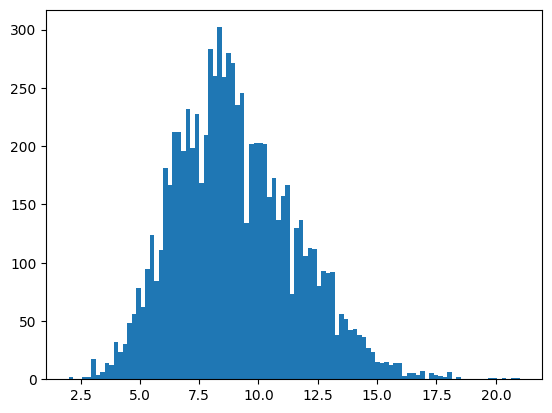

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [11]:
true_alpha = -9
## true_alpha = -np.median(scores)

In [12]:
logit_scores = logit_partial_scores(scores, true_alpha)

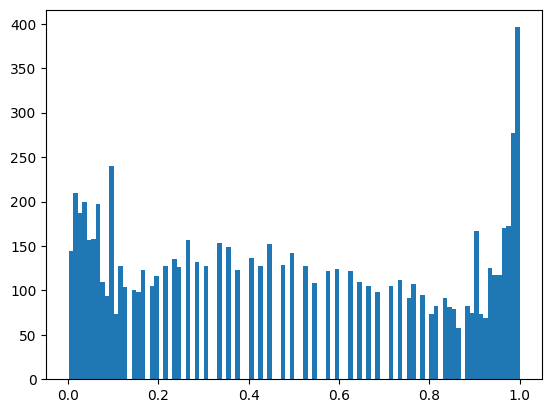

In [13]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

### Test Run

In [14]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False, False,  True], shape=(8193,))

In [ ]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL) ## This is different 

Sum of log-logit scores: -10002.78024009512
True LogL: -3250.980240095122


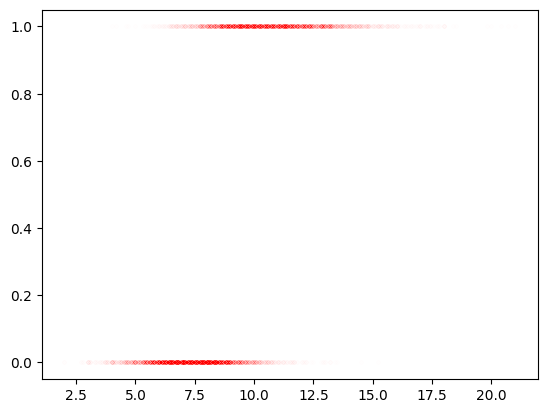

In [16]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

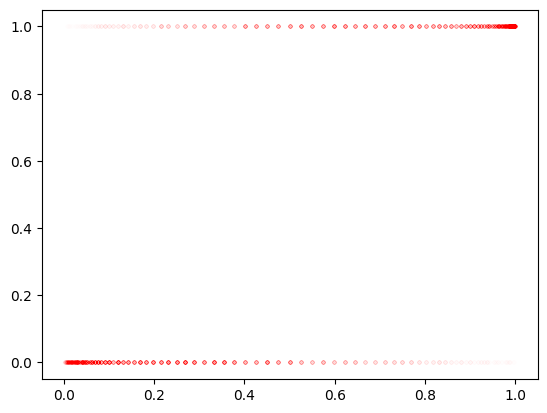

In [17]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [18]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [19]:
NITER = 50 # original 50

In [20]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

Alphabet:
CTGA


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Initial parameters:
{'alpha': np.float64(-8.558320546402097), 'match_score': np.float64(0.9644246094369797), 'mismatch_score': np.float64(-0.801858095042749), 'open_gap_score': np.float64(-1.2265763257494693), 'extend_gap_score': np.float64(-0.08767446999446553)}
Start of iteration 0
Current alpha: -8.558320546402097
Current logL: -3291.8646753486373
Updated alpha: -8.72523279015077
Updated logL: -3276.5855294780795
New subgradient:
{'Substitutions': Array([[-72.41132008, -12.81333073, -19.10906453,  -1.47090086],
       [-24.37877615, 109.91819444, -31.42953575, -26.96837299],
       [-13.06899874,  -6.18248702,  97.36465913, -18.5773625 ],
       [-10.80731732, -36.36297557, -26.69388567,  64.34869035]],
         alphabet='CTGA'), 'Gap opens': np.float64(185.0409305811498), 'Gap extends': np.float64(377.42854296721646)}
Stepsize: 1e-05
Gap open step: 0.0018504093058114982
Gap extend step: 0.003774285429672165
Match step: 0.0019922022383052716
Mismatch step: -0.0022786300782059567
New

In [21]:
print(params['final_loglik'])

-3255.1933787128605


In [22]:
print(params['final_loglik'])

-3255.1933787128605


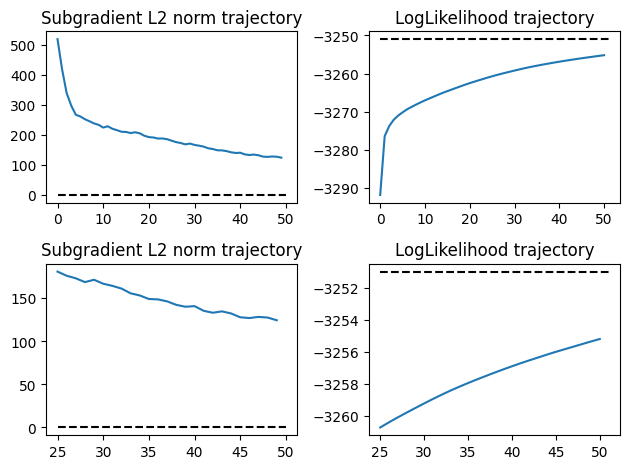

In [23]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

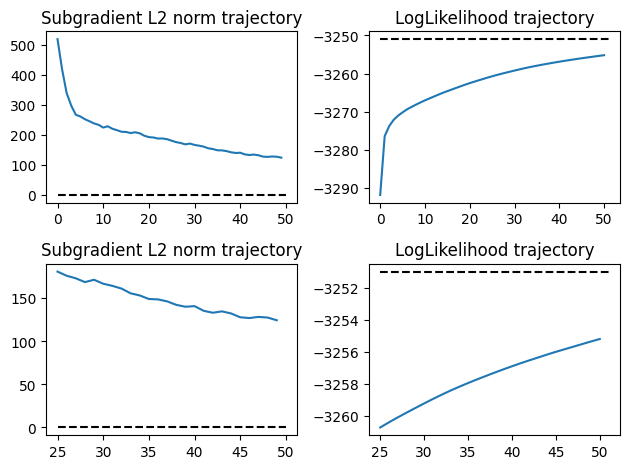

In [24]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [25]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 0.9828821808507527
-1 -0.8873158188939172
-1.2 -1.194829235721551
-0.1 -0.0853929869946203
-9 -9.005097351855943


### Additional plotting

In [26]:
# ## Freezing dataset values so true loglikliehood is not recomputed after every iteration 

# rng = np.random.default_rng(0)

# # fixed labels 
# labels_frozen = rng.random(len(mirlist)) <= logit_partial_scores(scores, true_alpha)

# # fixed model probabilities for true log-likelihood
# logit_scores_frozen = logit_partial_scores(scores, true_alpha)

# # compute true log-likelihood ONCE
# true_logL_frozen = (
#     np.sum(np.log(logit_scores_frozen[labels_frozen])) +
#     np.sum(np.log(1 - logit_scores_frozen[~labels_frozen]))
# )

In [27]:
# # Run estimalign across different step sizes and plot:
# # (1) logL trajectories to see convergence behavior
# # (2) scatter of convergence speed vs final parameter error to find the best step size

# step_sizes = [0.000005, 0.00001, 0.00005, 0.0001, 0.0005]
# task1_results = {}

# for ss in step_sizes:
#     step = create_constant_step(ss)
#     p = estimalign(mirlist, genelist, labels_frozen, ## labels_frozen now used 
#                    stepfunction=step, aligner_mode='local',
#                    substitution_mode='simple', verbose=False,
#                    max_iter=NITER, stochastic_factor=None, num_threads=16)
#     task1_results[ss] = p

# # Trajectory plot
# plt.figure()
# for ss, p in task1_results.items():
#     plt.plot(p['loglik_trajectory'], label=f'step={ss}')
# plt.axhline(true_logL, color='k', linestyle='--', label='True LogL')
# plt.xlabel('Iteration'); plt.ylabel('LogL')
# plt.title('LogL Trajectories by Step Size')
# plt.legend(); plt.tight_layout(); plt.show()

# # Scatter: convergence speed vs final parameter error
# def param_error(p):
#     return (abs(p['match_score'] - true_match) +
#             abs(p['mismatch_score'] - true_mismatch) +
#             abs(p['open_gap_score'] - true_gapopen) +
#             abs(p['extend_gap_score'] - true_gapext) +
#             abs(p['alpha'] - true_alpha))

# # convergence = first iteration where subgradient L2 norm drops below threshold
# threshold = 0.01
# conv_iters = []
# errors = []
# for ss, p in task1_results.items():
#     grads = p['subgradient_l2_trajectory']
#     conv = next((i for i, g in enumerate(grads) if g < threshold), NITER)
#     conv_iters.append(conv)
#     errors.append(param_error(p))

# plt.figure()
# for i, ss in enumerate(step_sizes):
#     plt.scatter(conv_iters[i], errors[i], label=f'step={ss}', s=100)
# plt.xlabel('Iterations to Converge')
# plt.ylabel('Total Parameter Error')
# plt.title('Convergence Speed vs Parameter Error')
# plt.legend(); plt.tight_layout(); plt.show()

In [28]:
# # Run estimalign 20 times with different random seeds and plot:
# # 1) a histogram of mean parameter error per run
# # 2) per-parameter boxplots to show which parameters are reliably recovered

# N_SEEDS = 20
# best_step = 0.000005 # best step size from task 1 

# # If we treat alpha as a single constant parameter then there wont be any error, so I removed it
# # For some reason doing that changes all of the error to the same bins  

# param_names = ['match_score', 'mismatch_score', 'open_gap_score', 'extend_gap_score']
# true_values = [true_match, true_mismatch, true_gapopen, true_gapext]

# per_param_errors = {name: [] for name in param_names}
# mean_errors = []

# for seed in range(N_SEEDS):
#     rd.seed(seed)

#     p = estimalign(mirlist, genelist, labels_frozen, ## changed labels to labels_frozen
#                    stepfunction=create_constant_step(best_step), aligner_mode='local',
#                    substitution_mode='simple', verbose=False,
#                    max_iter=NITER, stochastic_factor=None, num_threads=16)

#     errors = []
#     for name, true_val in zip(param_names, true_values):
#         err = abs(p[name] - true_val)
#         per_param_errors[name].append(err)
#         errors.append(err)

#     mean_errors.append(np.mean(errors))

# # Histogram: mean error per run
# plt.figure()
# plt.hist(mean_errors, bins=10, edgecolor='black')
# plt.xlabel('Mean Absolute Parameter Error')
# plt.ylabel('Count')
# plt.title('Distribution of Mean Parameter Error Across 20 Runs')
# plt.tight_layout()
# plt.show()

# # Boxplots: per-parameter error 
# plt.figure()
# plt.boxplot(per_param_errors.values(), labels=param_names, showfliers=True)
# plt.ylabel('Mean Absolute Error')
# plt.title('Per-Parameter Recovery Error Across 20 Runs')
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

### Step function parameters experiment

In [29]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [30]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [31]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [32]:
NITER = 10

In [ ]:
# Get the iteration at which convergence happens 
def get_convergence_iter(gradients, threshold = 0.01):
    for iteration, grad_val in enumerate(gradients):
        if grad_val < threshold:
            return iteration
    return NITER

In [ ]:
# Get the best step size from the first experiment

def step_score(params, true_logL, conv_iter, NITER):
    final_logL = params['loglik_trajectory'][-1]

    # 1. quality (how close to best achievable)
    quality = true_logL - final_logL

    # 2. speed penalty (normalized)
    speed = conv_iter / NITER

    # 3. failure penalty (if no convergence)
    if conv_iter == NITER:
        failure_penalty = 1.0
    else:
        failure_penalty = 0.0

    return quality + speed + failure_penalty

In [ ]:
estimalign_results = []
conv_iters = []

scores = []

for stepl in steplengths:
    const_step = create_constant_step(stepl)
    
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results.append(params)
    
for stepl, params in zip(steplengths, estimalign_results):
    conv_iter = get_convergence_iter(
        params['subgradient_l2_trajectory'],
        threshold=0.01
    )

    score = step_score(params, true_logL, conv_iter, NITER)
    scores.append(score)
    print(f"step={stepl:.2e}, score={score:.4f}, conv={conv_iter}")

    if conv_iter < NITER:
        print(f"step={stepl} converged at iteration {conv_iter}")
    else:
        print(f"step={stepl} did NOT converge")

best_step = steplengths[np.argmin(scores)]

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

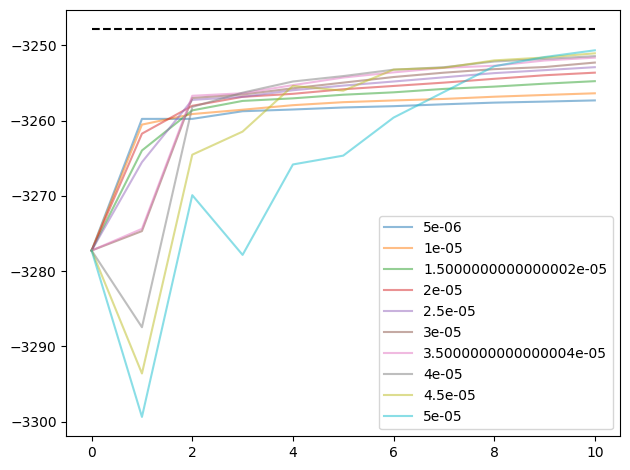

In [ ]:
plt.figure()
for params in estimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.2e}" for sl in steplengths])
plt.tight_layout()
# plt.savefig('path', dpi=160)

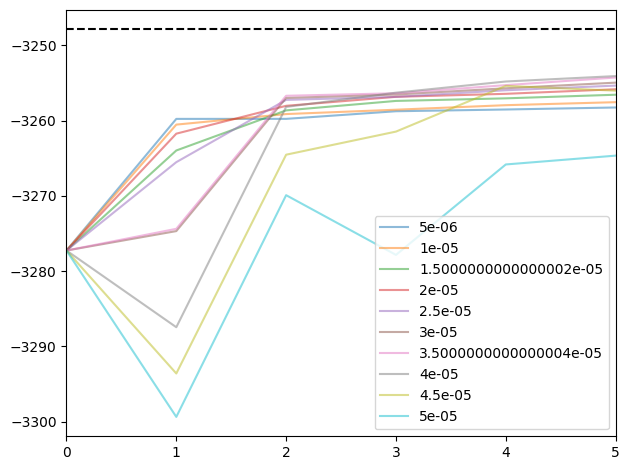

In [ ]:
plt.figure()
for params in estimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.2e}" for sl in steplengths])
plt.xlim(0, 5)
plt.tight_layout()

### Replicates

In [36]:
REPS = 20
NITER = 5

In [ ]:
const_step = create_constant_step(best_step) # updated to choose best step from prev exp
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [ ]:
estimalign_results = []
true_logLs = []
conv_iters_rep = [] # Checks if the chosen step size is stable in convergence across different datasets

for _ in range(REPS):
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    true_logLs.append(true_logL)
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results.append(params)

    conv_iters_rep.append(
        get_convergence_iter(
            params['subgradient_l2_trajectory'],
            threshold=0.01
        )
    )

for i, it in enumerate(conv_iters_rep):
    if it < NITER:
        print(f"rep {i} converged at iteration {it}")
    else:
        print(f"rep{i} did NOT converge")

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

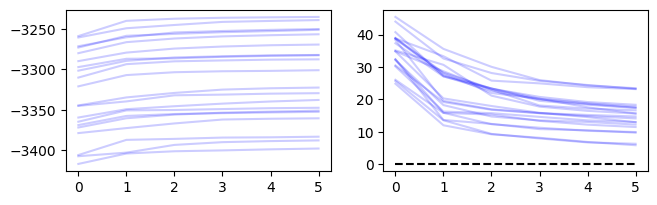

In [39]:
plt.figure(figsize=(7.5, 2.1))
plt.subplot(121)
for params in estimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.2, color='b')
plt.subplot(122)
plt.plot([0, NITER], [0, 0], 'k--')
for params, tlL in zip(estimalign_results, true_logLs):
    plt.plot(np.arange(NITER+1), tlL - params['loglik_trajectory'], alpha=0.2, color='b')

### General matrix, affine gap penalty

In [40]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [41]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [42]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

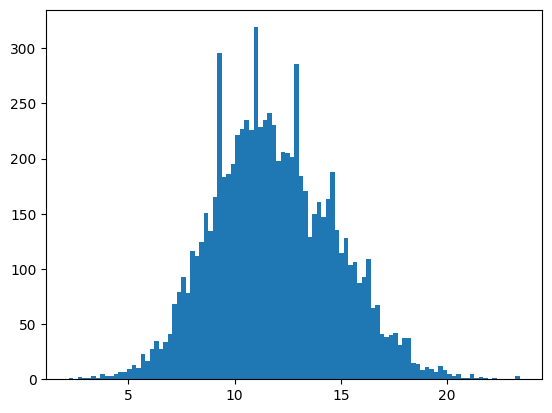

In [43]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [44]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

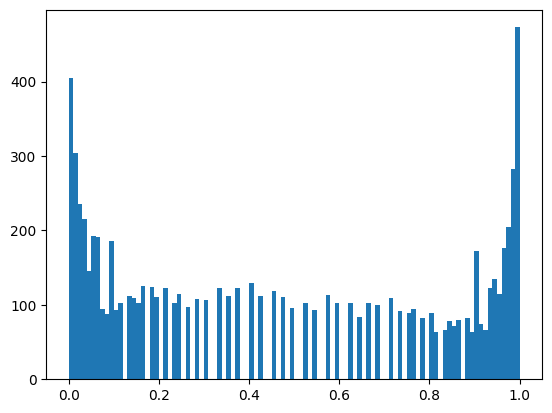

In [45]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [46]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -2984.730850414926


In [47]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [48]:
NITER = 200

In [49]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
CTGA
Initial parameters:
{'alpha': np.float64(-9.156648223617143), 'substitution_matrix': Array([[ 1.03520923, -0.19635152, -0.86837331, -0.62956994],
       [-0.5026452 ,  0.81820599, -0.81669465, -0.92564401],
       [-0.76894682, -0.81164821,  1.10953513, -0.45628952],
       [-0.46960824, -0.79912331, -0.70943487,  0.86610756]],
         alphabet='CTGA'), 'open_gap_score': np.float64(-1.223696819787341), 'extend_gap_score': np.float64(-0.07298073350094376)}
Start of iteration 0
Current alpha: -9.156648223617143
Current logL: -3083.7552893733673
Updated alpha: -9.452299499935515
Updated logL: -3037.586482555695
New subgradient:
{'Substitutions': Array([[120.75751603,  -4.15515717,   4.363907  ,   3.66330353],
       [ 12.97879075, 168.86583303,  -2.68896744,  -6.27634961],
       [-31.13350919, -22.61139811, 187.96414355,  22.6929955 ],
       [ 13.8963898 ,  -3.53216214, -19.28211195, 117.89478487]],
         alphabet='CTGA'), 'Gap opens': np.float64(277.27476788087324), 

KeyboardInterrupt: 

In [ ]:
print(params['final_loglik'])

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector))))

In [ ]:
plt.figure()
plt.plot(true_subs_vector, param_subs_vector, 'r.')

In [ ]:
from src.optimization import get_initial_estimate

In [ ]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

In [ ]:
true_substitution

In [ ]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [ ]:
estim_substitution